# 01 — Data Exploration

Sanity-check all input datasets before analysis:
- WBGT daily GeoTIFFs (CHIRTS-ERA5)
- Population raster (1 km)
- Relative Wealth Index raster (2.4 km)
- Country boundaries

In [22]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import yaml

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

with open(ROOT / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

DATA = ROOT / 'data'
print('Project root:', ROOT)

Project root: E:\Projects\Howden\Heatwaves\howden_heat


## 1. WBGT — check a sample file

In [11]:
# List available WBGT files
wbgt_dir = DATA / 'wbgt'
wbgt_files = sorted(wbgt_dir.glob('WBGT.*.tif'))
print(f'WBGT files found: {len(wbgt_files)}')
if wbgt_files:
    print('First:', wbgt_files[0].name)
    print('Last: ', wbgt_files[-1].name)

WBGT files found: 365
First: WBGT.2025.01.01.tif
Last:  WBGT.2025.12.31.tif


CRS:        EPSG:4326
Resolution: (0.05000000074505806, 0.05000000074505806)
Shape:      (2600, 7200)
Bounds:     BoundingBox(left=-180.0, bottom=-60.000001937150955, right=180.00000536441803, top=70.0)
Nodata:     None

Value range: -9999.0 - 33.5 °C


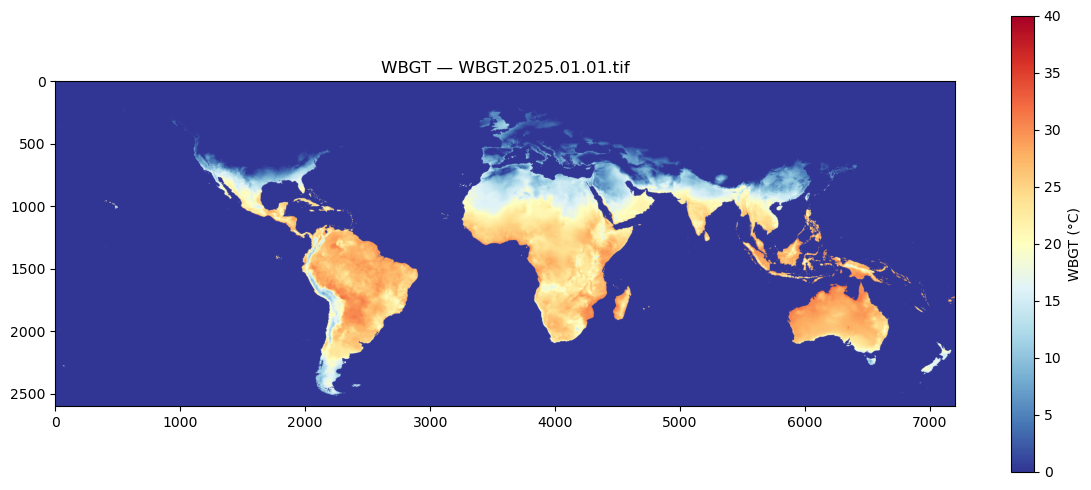

In [12]:
# Inspect one file
sample_file = wbgt_files[0] if wbgt_files else None

if sample_file:
    with rasterio.open(sample_file) as src:
        print('CRS:       ', src.crs)
        print('Resolution:', src.res)
        print('Shape:     ', src.shape)
        print('Bounds:    ', src.bounds)
        print('Nodata:    ', src.nodata)
        arr = src.read(1).astype(float)
        arr[arr == src.nodata] = np.nan

    print(f'\nValue range: {np.nanmin(arr):.1f} - {np.nanmax(arr):.1f} °C')

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(arr, cmap='RdYlBu_r', vmin=0, vmax=40)
    plt.colorbar(im, ax=ax, label='WBGT (°C)')
    ax.set_title(f'WBGT — {sample_file.name}')
    plt.tight_layout()
    plt.show()

## 2. Population raster

CRS:        EPSG:4326
Resolution: (0.0083333333, 0.0083333333)
Shape:      (17280, 43200)
Bounds:     BoundingBox(left=-180.0, bottom=-59.99999942400001, right=179.99999856000005, top=84.0)
Nodata:     -99999.0

Total population (approx): 9,491,440


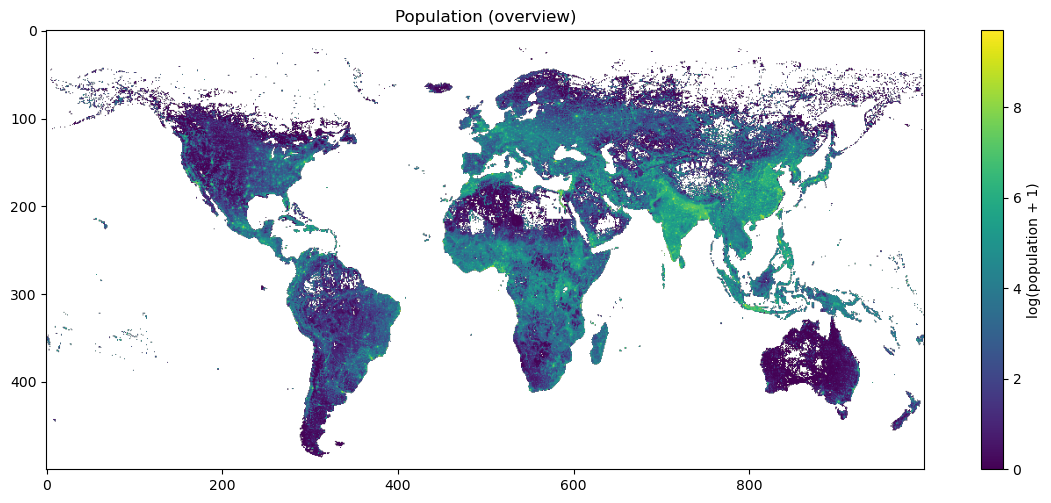

In [15]:
pop_path = ROOT / config['data']['population']

with rasterio.open(pop_path) as src:
    print('CRS:       ', src.crs)
    print('Resolution:', src.res)
    print('Shape:     ', src.shape)
    print('Bounds:    ', src.bounds)
    print('Nodata:    ', src.nodata)
    # Read a small overview to avoid loading full raster
    pop_overview = src.read(1, out_shape=(500, 1000), resampling=rasterio.enums.Resampling.average)

pop_overview = pop_overview.astype(float)
pop_overview[pop_overview < 0] = np.nan
print(f'\nTotal population (approx): {np.nansum(pop_overview):,.0f}')

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(np.log1p(pop_overview), cmap='viridis')
plt.colorbar(im, ax=ax, label='log(population + 1)')
ax.set_title('Population (overview)')
plt.tight_layout()
plt.show()

## 3. Relative Wealth Index

CRS:        EPSG:3857
Resolution: (2445.9786434, 2445.96770335)
Shape:      (6051, 11749)
Bounds:     BoundingBox(left=-13039545.521571599, bottom=-7357418.615290595, right=15698257.559735, top=7443131.957680255)
Nodata:     -999.0

RWI range: -1.58 to 1.46


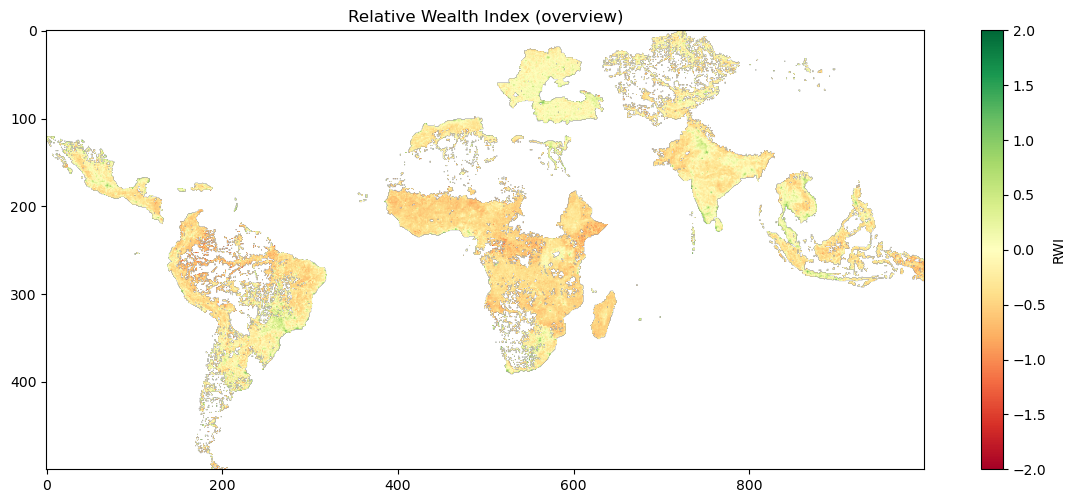

In [18]:
rwi_path = ROOT / config['data']['rwi']

with rasterio.open(rwi_path) as src:
    print('CRS:       ', src.crs)
    print('Resolution:', src.res)
    print('Shape:     ', src.shape)
    print('Bounds:    ', src.bounds)
    print('Nodata:    ', src.nodata)
    rwi_overview = src.read(1, out_shape=(500, 1000), resampling=rasterio.enums.Resampling.average)

rwi_overview = rwi_overview.astype(float)
rwi_overview[rwi_overview == -999] = np.nan
print(f'\nRWI range: {np.nanmin(rwi_overview):.2f} to {np.nanmax(rwi_overview):.2f}')

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rwi_overview, cmap='RdYlGn', vmin=-2, vmax=2)
plt.colorbar(im, ax=ax, label='RWI')
ax.set_title('Relative Wealth Index (overview)')
plt.tight_layout()
plt.show()

## 4. Country boundaries

Boundary file columns: ['fid', 'id', 'shapeGroup', 'shapeType', 'shapeName', 'geometry']
Total countries: 218
LMICs matched: 92 / 92


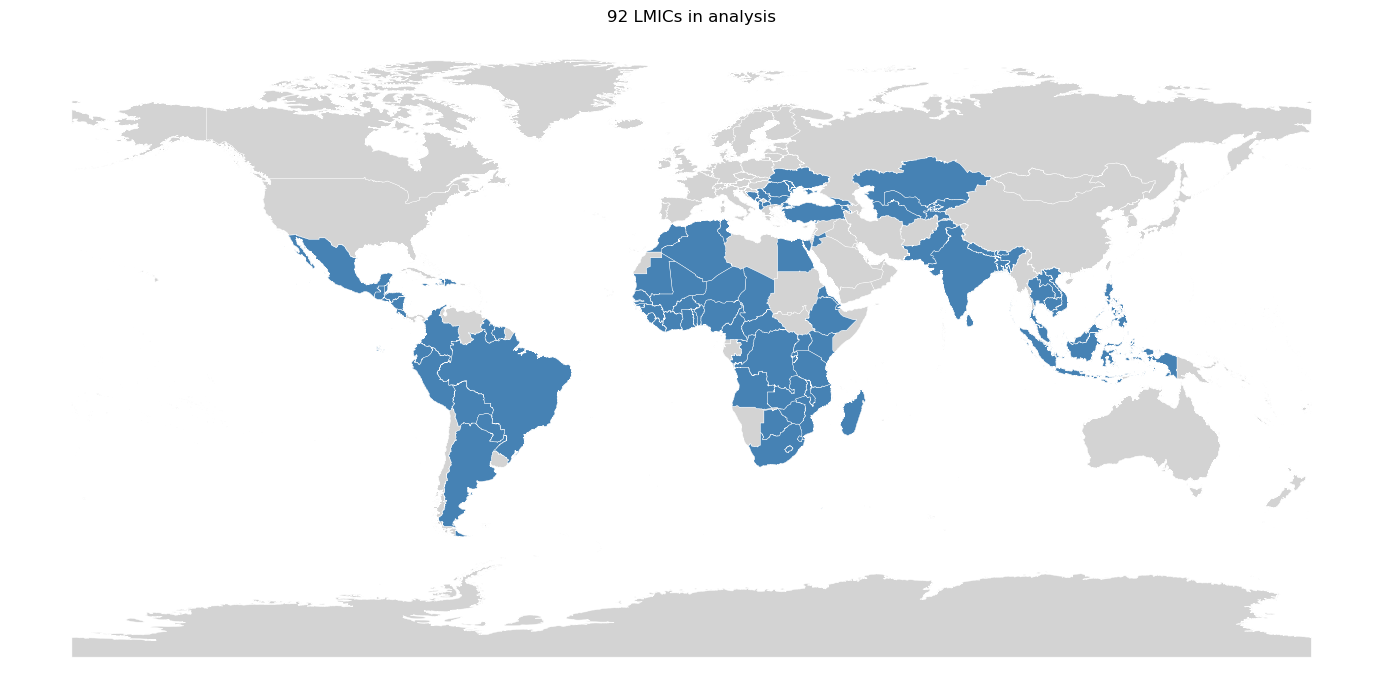

In [23]:
boundaries_path = ROOT / config['data']['boundaries']
iso_codes = config['iso_codes']

world = gpd.read_file(boundaries_path)
print('Boundary file columns:', list(world.columns))
print('Total countries:', len(world))

# Identify which ISO column to use
for col in ['ADM0_A3', 'ISO_A3', 'iso_a3', 'GID_0', 'shapeGroup']:
    if col in world.columns:
        iso_col = col
        break

lmics = world[world[iso_col].isin(iso_codes)]
print(f'LMICs matched: {len(lmics)} / {len(iso_codes)}')

missing = set(iso_codes) - set(lmics[iso_col])
if missing:
    print('Missing:', sorted(missing))

fig, ax = plt.subplots(figsize=(14, 7))
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)
lmics.plot(ax=ax, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title('92 LMICs in analysis')
ax.axis('off')
plt.tight_layout()
plt.show()